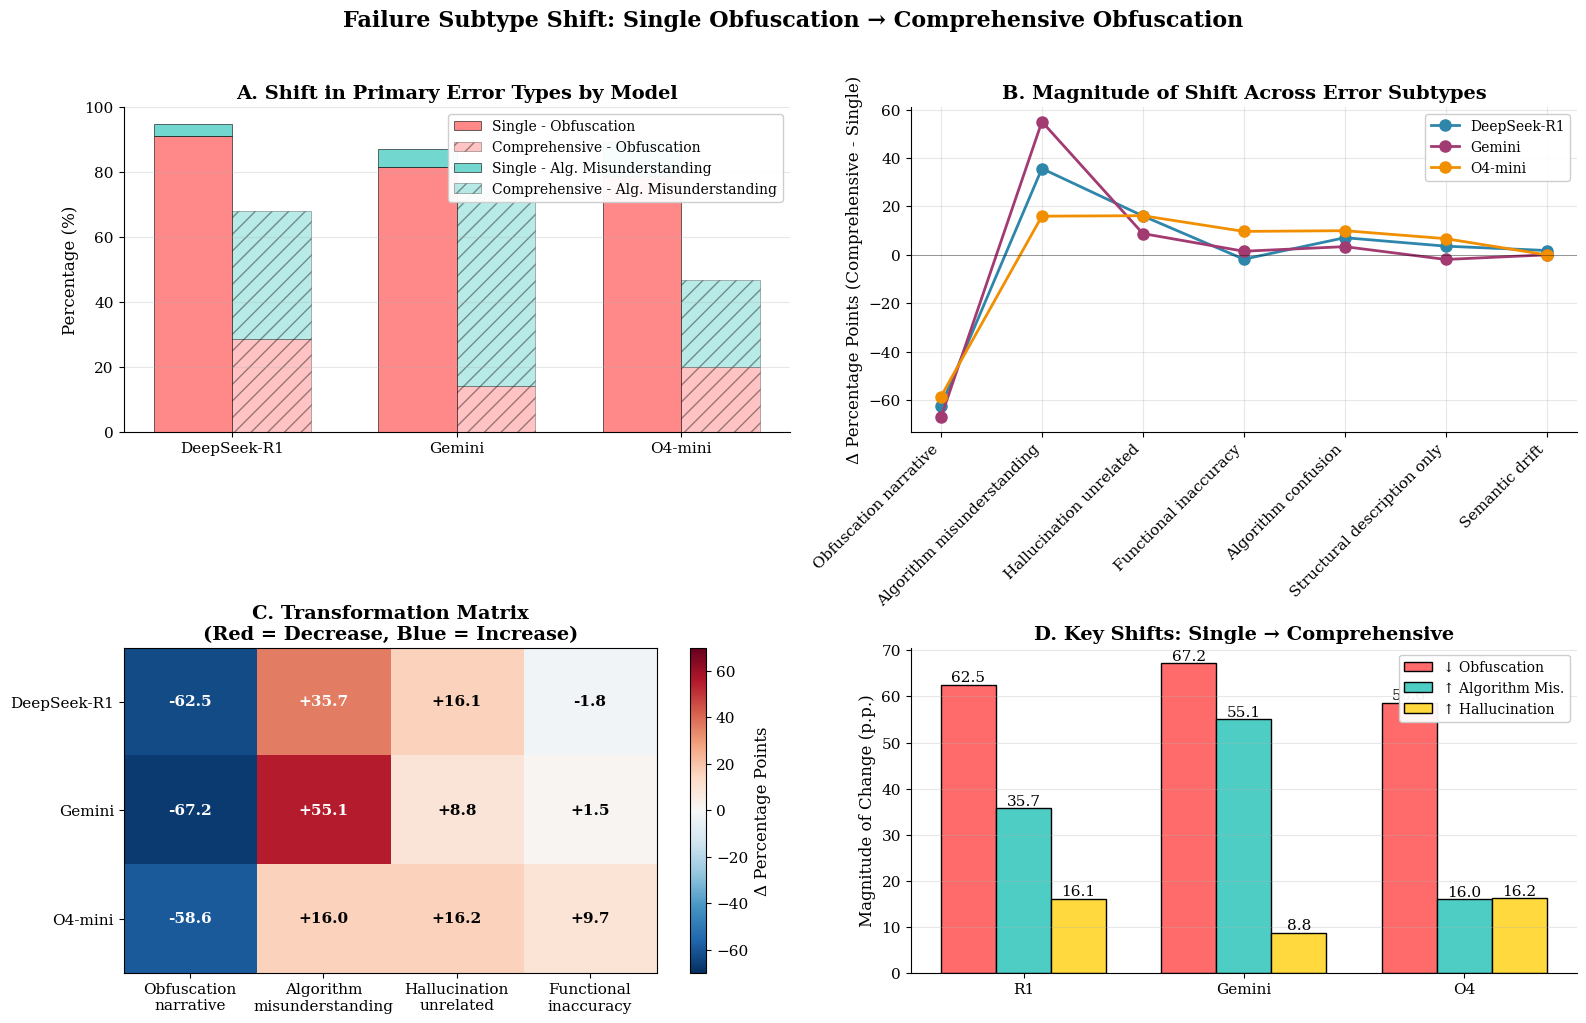

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set style for academic publication
plt.style.use('default')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16

# Data preparation
data = {
    'DeepSeek-R1': {
        'Obfuscation_narrative': [91.1, 28.6],
        'Algorithm_misunderstanding': [3.6, 39.3],
        'Hallucination_unrelated': [1.8, 17.9],
        'Functional_inaccuracy': [1.8, 0.0],
        'Algorithm_confusion': [0.0, 7.1],
        'Structural_description_only': [0.0, 3.6],
        'Semantic_drift': [1.8, 3.6]
    },
    'Gemini': {
        'Obfuscation_narrative': [81.5, 14.3],
        'Algorithm_misunderstanding': [5.6, 60.7],
        'Hallucination_unrelated': [1.9, 10.7],
        'Functional_inaccuracy': [5.6, 7.1],
        'Algorithm_confusion': [3.7, 7.1],
        'Structural_description_only': [1.9, 0.0],
        'Semantic_drift': [0.0, 0.0]
    },
    'O4-mini': {
        'Obfuscation_narrative': [78.6, 20.0],
        'Algorithm_misunderstanding': [10.7, 26.7],
        'Hallucination_unrelated': [7.1, 23.3],
        'Functional_inaccuracy': [3.6, 13.3],
        'Algorithm_confusion': [0.0, 10.0],
        'Structural_description_only': [0.0, 6.7],
        'Semantic_drift': [0.0, 0.0]
    }
}

# Create figure with subplots
fig = plt.figure(figsize=(16, 10))

# Color scheme
colors = plt.cm.Set3(np.linspace(0, 1, 7))
model_colors = {'DeepSeek-R1': '#2E86AB', 'Gemini': '#A23B72', 'O4-mini': '#F18F01'}

# 1. Main panel: Grouped bar chart showing shift for each model
ax1 = plt.subplot(2, 2, 1)
models = list(data.keys())
x = np.arange(len(models))
width = 0.35

single_means = [sum(data[m]['Obfuscation_narrative']) for m in models]  # Just for scaling
comprehensive_means = [data[m]['Algorithm_misunderstanding'][1] for m in models]

# Create grouped bars for Single vs Comprehensive (only showing key categories for clarity)
single_obf = [data[m]['Obfuscation_narrative'][0] for m in models]
comp_obf = [data[m]['Obfuscation_narrative'][1] for m in models]
single_alg_mis = [data[m]['Algorithm_misunderstanding'][0] for m in models]
comp_alg_mis = [data[m]['Algorithm_misunderstanding'][1] for m in models]

bars1 = ax1.bar(x - width/2, single_obf, width, label='Single - Obfuscation', color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=0.5)
bars2 = ax1.bar(x + width/2, comp_obf, width, label='Comprehensive - Obfuscation', color='#FF6B6B', alpha=0.4, edgecolor='black', linewidth=0.5, hatch='//')
bars3 = ax1.bar(x - width/2, single_alg_mis, width, bottom=single_obf, label='Single - Alg. Misunderstanding', color='#4ECDC4', alpha=0.8, edgecolor='black', linewidth=0.5)
bars4 = ax1.bar(x + width/2, comp_alg_mis, width, bottom=comp_obf, label='Comprehensive - Alg. Misunderstanding', color='#4ECDC4', alpha=0.4, edgecolor='black', linewidth=0.5, hatch='//')

ax1.set_ylabel('Percentage (%)')
ax1.set_title('A. Shift in Primary Error Types by Model', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend(loc='upper right', framealpha=0.95)
ax1.set_ylim(0, 100)
ax1.grid(True, alpha=0.3, axis='y')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 2. Delta plot showing change for each subtype across models
ax2 = plt.subplot(2, 2, 2)
subtypes = ['Obfuscation_narrative', 'Algorithm_misunderstanding', 'Hallucination_unrelated', 
            'Functional_inaccuracy', 'Algorithm_confusion', 'Structural_description_only', 'Semantic_drift']
x2 = np.arange(len(subtypes))

for i, model in enumerate(models):
    deltas = [data[model][st][1] - data[model][st][0] for st in subtypes]
    ax2.plot(x2, deltas, marker='o', linewidth=2, markersize=8, label=model, color=model_colors[model])

ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.set_xticks(x2)
ax2.set_xticklabels([st.replace('_', ' ') for st in subtypes], rotation=45, ha='right')
ax2.set_ylabel('Δ Percentage Points (Comprehensive - Single)')
ax2.set_title('B. Magnitude of Shift Across Error Subtypes', fontweight='bold')
ax2.legend(framealpha=0.95)
ax2.grid(True, alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 3. Heatmap showing the transformation
ax3 = plt.subplot(2, 2, 3)
# Prepare data for heatmap (only top 4 subtypes for clarity)
heatmap_data = []
for model in models:
    row = []
    for st in subtypes[:4]:  # Top 4 subtypes
        row.append(data[model][st][1] - data[model][st][0])
    heatmap_data.append(row)

im = ax3.imshow(heatmap_data, cmap='RdBu_r', aspect='auto', vmin=-70, vmax=70)
ax3.set_xticks(np.arange(len(subtypes[:4])))
ax3.set_yticks(np.arange(len(models)))
ax3.set_xticklabels([st.replace('_', '\n') for st in subtypes[:4]])
ax3.set_yticklabels(models)
ax3.set_title('C. Transformation Matrix\n(Red = Decrease, Blue = Increase)', fontweight='bold')

# Add text annotations
for i in range(len(models)):
    for j in range(len(subtypes[:4])):
        value = heatmap_data[i][j]
        text_color = 'white' if abs(value) > 35 else 'black'
        ax3.text(j, i, f'{value:+.1f}', ha='center', va='center', color=text_color, fontweight='bold')

plt.colorbar(im, ax=ax3, label='Δ Percentage Points')

# 4. Summary statistics
ax4 = plt.subplot(2, 2, 4)
# Calculate overall shift metrics
models_short = ['R1', 'Gemini', 'O4']
obf_decrease = [data[m]['Obfuscation_narrative'][0] - data[m]['Obfuscation_narrative'][1] for m in models]
alg_increase = [data[m]['Algorithm_misunderstanding'][1] - data[m]['Algorithm_misunderstanding'][0] for m in models]
hall_increase = [data[m]['Hallucination_unrelated'][1] - data[m]['Hallucination_unrelated'][0] for m in models]

x4 = np.arange(len(models_short))
width = 0.25

bars_obf = ax4.bar(x4 - width, obf_decrease, width, label='↓ Obfuscation', color='#FF6B6B', edgecolor='black')
bars_alg = ax4.bar(x4, alg_increase, width, label='↑ Algorithm Mis.', color='#4ECDC4', edgecolor='black')
bars_hall = ax4.bar(x4 + width, hall_increase, width, label='↑ Hallucination', color='#FFD93D', edgecolor='black')

ax4.set_ylabel('Magnitude of Change (p.p.)')
ax4.set_title('D. Key Shifts: Single → Comprehensive', fontweight='bold')
ax4.set_xticks(x4)
ax4.set_xticklabels(models_short)
ax4.legend(framealpha=0.95)
ax4.grid(True, alpha=0.3, axis='y')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# Add value labels on bars
for bars in [bars_obf, bars_alg, bars_hall]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom' if height > 0 else 'top')

plt.suptitle('Failure Subtype Shift: Single Obfuscation → Comprehensive Obfuscation', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save figure
plt.savefig('obfuscation_shift_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('obfuscation_shift_analysis.pdf', bbox_inches='tight', facecolor='white')

plt.show()

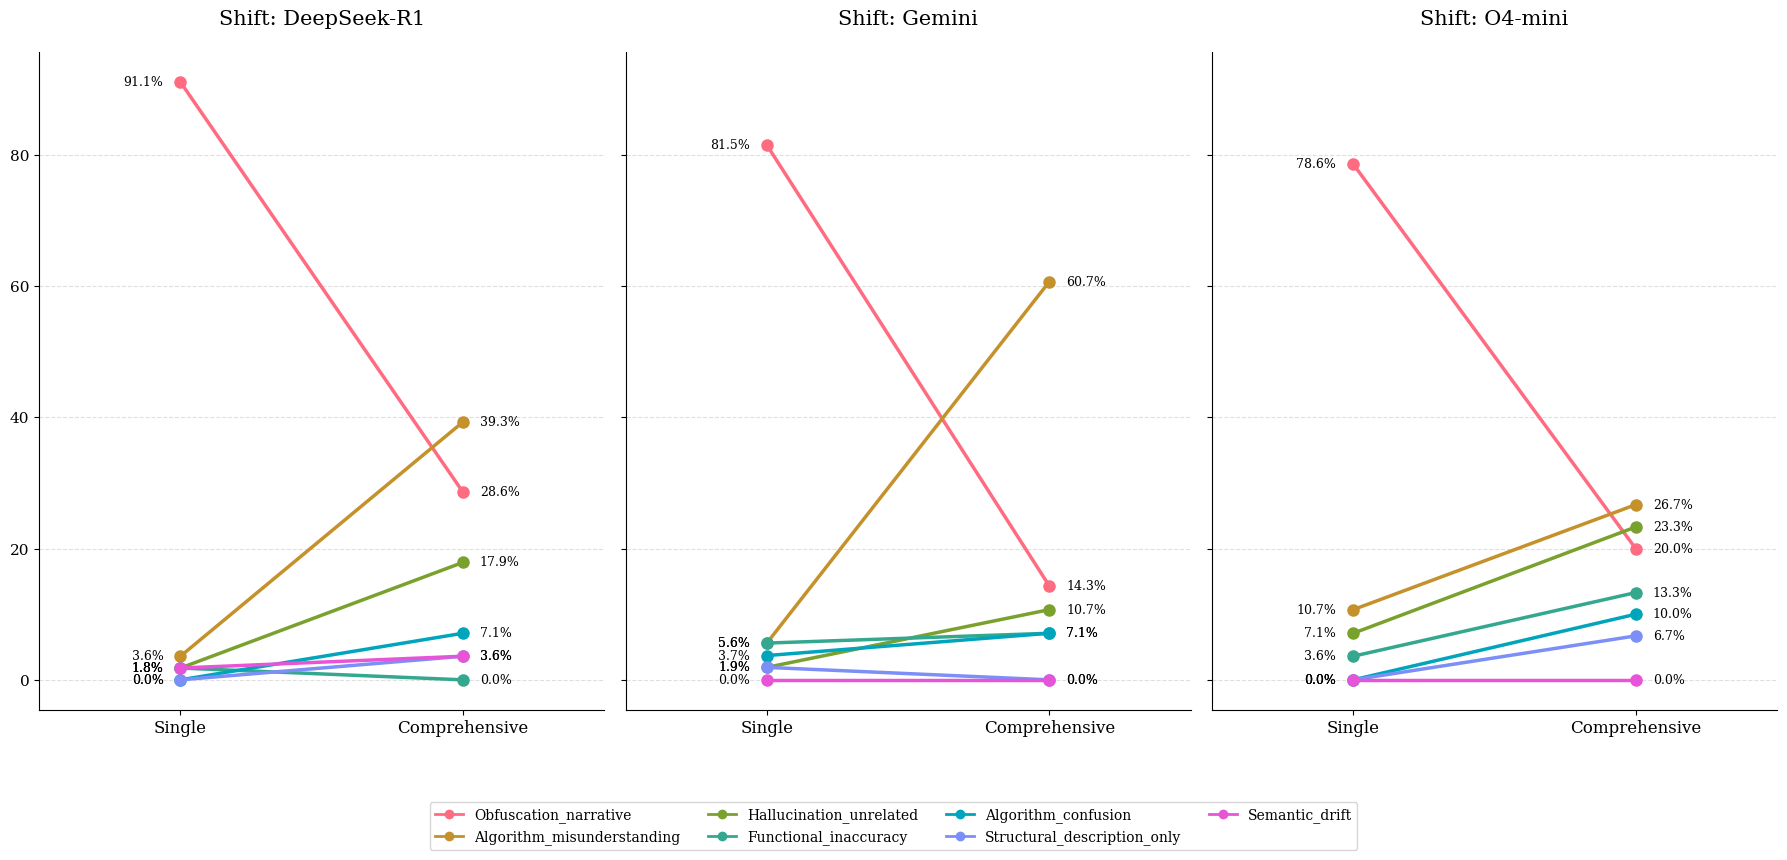

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1. Dataset Setup
data = [
    ["DeepSeek-R1", "Obfuscation_narrative", 91.1, 28.6],
    ["DeepSeek-R1", "Algorithm_misunderstanding", 3.6, 39.3],
    ["DeepSeek-R1", "Hallucination_unrelated", 1.8, 17.9],
    ["DeepSeek-R1", "Functional_inaccuracy", 1.8, 0.0],
    ["DeepSeek-R1", "Algorithm_confusion", 0.0, 7.1],
    ["DeepSeek-R1", "Structural_description_only", 0.0, 3.6],
    ["DeepSeek-R1", "Semantic_drift", 1.8, 3.6],
    
    ["Gemini", "Obfuscation_narrative", 81.5, 14.3],
    ["Gemini", "Algorithm_misunderstanding", 5.6, 60.7],
    ["Gemini", "Hallucination_unrelated", 1.9, 10.7],
    ["Gemini", "Functional_inaccuracy", 5.6, 7.1],
    ["Gemini", "Algorithm_confusion", 3.7, 7.1],
    ["Gemini", "Structural_description_only", 1.9, 0.0],
    ["Gemini", "Semantic_drift", 0.0, 0.0],
    
    ["O4-mini", "Obfuscation_narrative", 78.6, 20.0],
    ["O4-mini", "Algorithm_misunderstanding", 10.7, 26.7],
    ["O4-mini", "Hallucination_unrelated", 7.1, 23.3],
    ["O4-mini", "Functional_inaccuracy", 3.6, 13.3],
    ["O4-mini", "Algorithm_confusion", 0.0, 10.0],
    ["O4-mini", "Structural_description_only", 0.0, 6.7],
    ["O4-mini", "Semantic_drift", 0.0, 0.0],
]

df = pd.DataFrame(data, columns=["Model", "Subtype", "Single", "Comprehensive"])

# 2. Color Palette (Matching your image)
color_map = {
    "Obfuscation_narrative": "#FF6B81",           # Pink
    "Algorithm_misunderstanding": "#C4912B",      # Gold
    "Hallucination_unrelated": "#7AA12E",         # Olive
    "Functional_inaccuracy": "#34A88E",           # Teal/Green
    "Algorithm_confusion": "#00A5BC",              # Cyan
    "Structural_description_only": "#7B8FF7",      # Periwinkle
    "Semantic_drift": "#E854D8"                    # Magenta
}

# 3. Plotting (only relevant shifts to avoid overlapping single-score labels)
SHIFT_THRESHOLD = 5.0  # minimum |Comprehensive - Single| to show
fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=True)
models = ["DeepSeek-R1", "Gemini", "O4-mini"]

for i, model in enumerate(models):
    ax = axes[i]
    model_df = df[df["Model"] == model].copy()
    model_df["Delta"] = (model_df["Comprehensive"] - model_df["Single"]).abs()
    model_df = model_df[model_df["Delta"] >= SHIFT_THRESHOLD].sort_values("Single", ascending=False)
    
    for _, row in model_df.iterrows():
        subtype = row["Subtype"]
        color = color_map[subtype]
        
        # Plot the transition lines
        ax.plot([0, 1], [row["Single"], row["Comprehensive"]], 
                marker='o', color=color, linewidth=2.5, markersize=8)
        
        # Add labels for start/end points
        ax.text(-0.06, row["Single"], f"{row['Single']}%", 
                ha='right', va='center', fontsize=9, fontweight='500')
        ax.text(1.06, row["Comprehensive"], f"{row['Comprehensive']}%", 
                ha='left', va='center', fontsize=9, fontweight='500')

    # Styling the subplot
    ax.set_title(model, fontsize=15, pad=20)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Single", "Comprehensive"], fontsize=12)
    ax.set_xlim(-0.5, 1.5) # Extra space for labels
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 4. Global Legend
legend_elements = [Line2D([0], [0], color=color, marker='o', lw=2, label=s) 
                   for s, color in color_map.items()]

fig.legend(handles=legend_elements, loc='lower center', ncol=4, 
           bbox_to_anchor=(0.5, -0.08), frameon=True, fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()



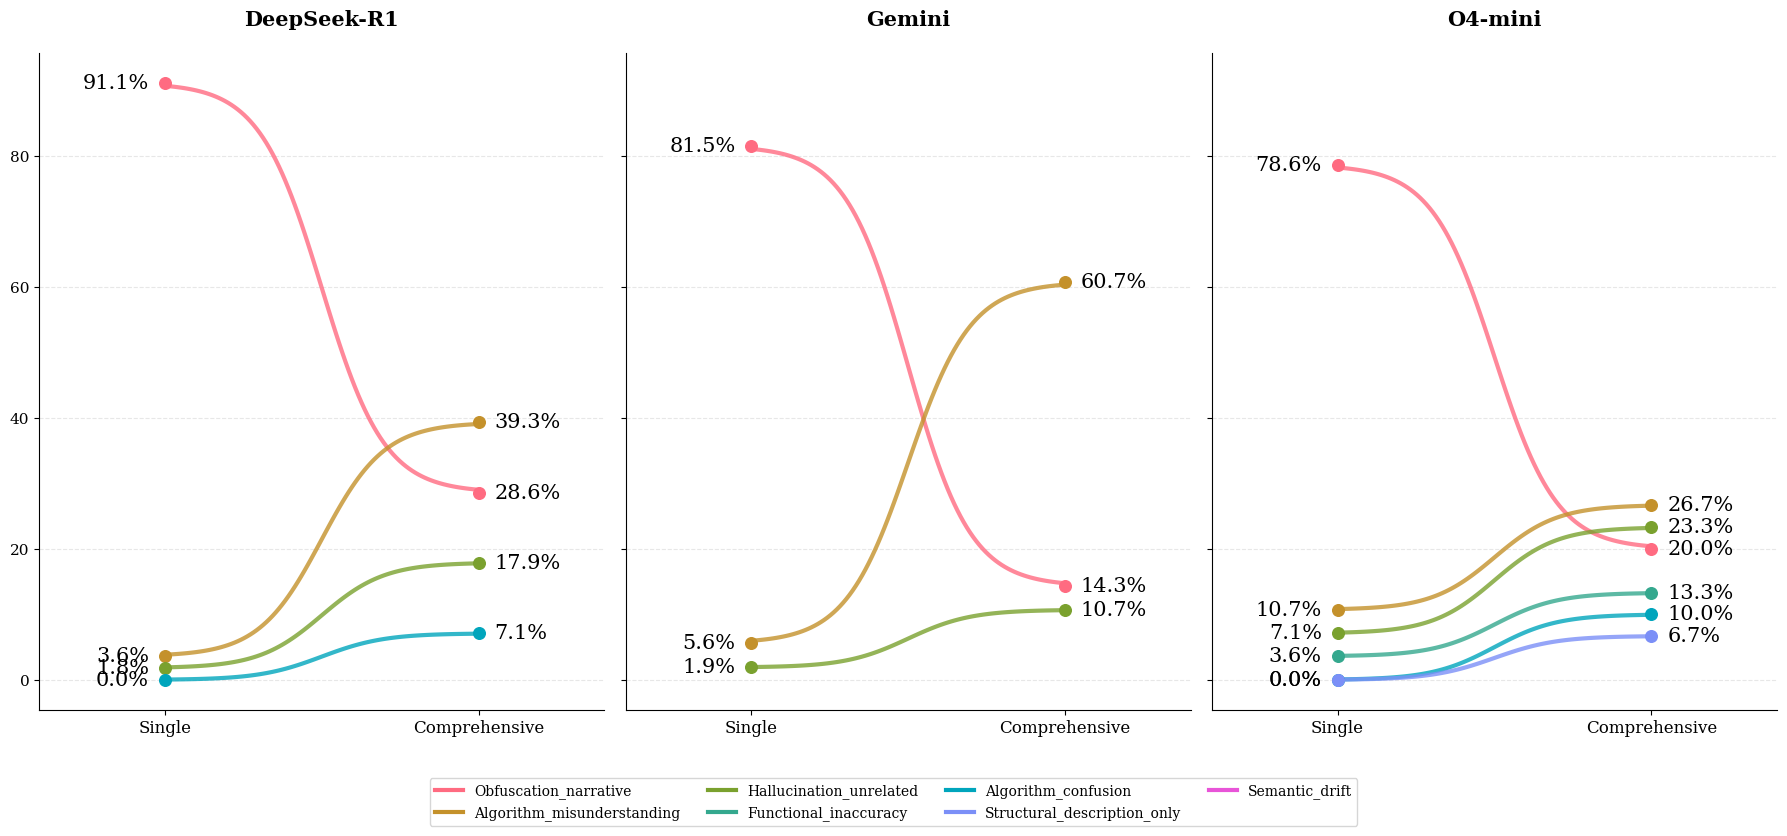

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Dataset Setup
data = [
    ["DeepSeek-R1", "Obfuscation_narrative", 91.1, 28.6],
    ["DeepSeek-R1", "Algorithm_misunderstanding", 3.6, 39.3],
    ["DeepSeek-R1", "Hallucination_unrelated", 1.8, 17.9],
    ["DeepSeek-R1", "Functional_inaccuracy", 1.8, 0.0],
    ["DeepSeek-R1", "Algorithm_confusion", 0.0, 7.1],
    ["DeepSeek-R1", "Structural_description_only", 0.0, 3.6],
    ["DeepSeek-R1", "Semantic_drift", 1.8, 3.6],
    
    ["Gemini", "Obfuscation_narrative", 81.5, 14.3],
    ["Gemini", "Algorithm_misunderstanding", 5.6, 60.7],
    ["Gemini", "Hallucination_unrelated", 1.9, 10.7],
    ["Gemini", "Functional_inaccuracy", 5.6, 7.1],
    ["Gemini", "Algorithm_confusion", 3.7, 7.1],
    ["Gemini", "Structural_description_only", 1.9, 0.0],
    ["Gemini", "Semantic_drift", 0.0, 0.0],
    
    ["O4-mini", "Obfuscation_narrative", 78.6, 20.0],
    ["O4-mini", "Algorithm_misunderstanding", 10.7, 26.7],
    ["O4-mini", "Hallucination_unrelated", 7.1, 23.3],
    ["O4-mini", "Functional_inaccuracy", 3.6, 13.3],
    ["O4-mini", "Algorithm_confusion", 0.0, 10.0],
    ["O4-mini", "Structural_description_only", 0.0, 6.7],
    ["O4-mini", "Semantic_drift", 0.0, 0.0],
]

df = pd.DataFrame(data, columns=["Model", "Subtype", "Single", "Comprehensive"])

# 2. Styling and Colors
color_map = {
    "Obfuscation_narrative": "#FF6B81",
    "Algorithm_misunderstanding": "#C4912B",
    "Hallucination_unrelated": "#7AA12E",
    "Functional_inaccuracy": "#34A88E",
    "Algorithm_confusion": "#00A5BC",
    "Structural_description_only": "#7B8FF7",
    "Semantic_drift": "#E854D8"
}

# 3. Plotting with Sigmoid Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=True)
models = ["DeepSeek-R1", "Gemini", "O4-mini"]

for i, model in enumerate(models):
    ax = axes[i]
    model_df = df[df["Model"] == model]
    
    for _, row in model_df.iterrows():
        subtype = row["Subtype"]
        color = color_map[subtype]
        y1, y2 = row["Single"], row["Comprehensive"]
        
        # Create a sigmoid curve between 0 and 1
        x = np.linspace(0, 1, 100)
        # S-curve: y = y1 + (y2 - y1) * (1 / (1 + exp(-10 * (x - 0.5))))
        y_curve = y1 + (y2 - y1) * (1 / (1 + np.exp(-10 * (x - 0.5))))
        
        # Plot curve and endpoints
        ax.plot(x, y_curve, color=color, linewidth=3, alpha=0.8)
        ax.scatter([0, 1], [y1, y2], color=color, s=70, zorder=5)
        
        # Annotate values
        ax.text(-0.05, y1, f"{y1}%", ha='right', va='center', fontsize=9)
        ax.text(1.05, y2, f"{y2}%", ha='left', va='center', fontsize=9)

    ax.set_title(f"Shift: {model}", fontsize=15, pad=20, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Single", "Comprehensive"], fontsize=12)
    ax.set_xlim(-0.4, 1.4)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

# Global Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=c, lw=3, label=s) for s, c in color_map.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()